# Thermal

Twenty nodes on one thermometer: the fit, the board's estimate and budget, the envelope, the room identified, a trip.

## 1 Setup

In [1]:
from coaxial import ExecutionMode

MODE = ExecutionMode.EMULATED   # the image on Renode, the stand-in where none runs; .HARDWARE and PORT at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, execution_mode=MODE).open()
print(device)

<Coaxial63100 Emulated MCU at emulator://>


## 2 The network, and how it was fitted

`coaxial.model.thermal` is the network `thermal/src/thermal.c` integrates: twenty nodes along the copper. Measured: `board_to_ambient` and `board_capacity` only.

In [3]:
from coaxial.model import thermal

print('ambient %.1f C assumed; board_to_ambient %.2f K/W at a %.0f K rise, '
      'board_capacity %.0f J/K, tau %.1f min'
      % (thermal.AMBIENT, thermal.CFG['board_to_ambient'], thermal.BOARD_CAL_RISE_K,
         thermal.CFG['board_capacity'], thermal.tau_minutes()))
print('%d nodes on %d edges: %d sources, %d of laminate, the hot swap, %d of motor'
      % (len(thermal.ALL_NODES), len(thermal.EDGES), len(thermal.NODES),
         len(thermal.LAMINATE), len(thermal.MOTOR)))
for node in thermal.NODES:
    print('%-12s to_board %5.1f K/W  capacity %.3f J/K'
          % (node, thermal.CFG['to_board'][node], thermal.CFG['capacity'][node]))

ambient 25.0 C assumed; board_to_ambient 8.33 K/W at a 10 K rise, board_capacity 49 J/K, tau 6.8 min
20 nodes on 30 edges: 9 sources, 7 of laminate, the hot swap, 3 of motor
driver_u     to_board  12.0 K/W  capacity 0.117 J/K
driver_v     to_board  12.0 K/W  capacity 0.117 J/K
driver_w     to_board  12.0 K/W  capacity 0.117 J/K
phase_u      to_board   8.0 K/W  capacity 0.400 J/K
phase_v      to_board   8.0 K/W  capacity 0.400 J/K
phase_w      to_board   8.0 K/W  capacity 0.400 J/K
mcu          to_board  22.5 K/W  capacity 0.900 J/K
regulators   to_board  15.0 K/W  capacity 0.800 J/K
afe          to_board  41.5 K/W  capacity 0.300 J/K


Camera, four states, each adding one power term, 25 min each (3.7 constants), dead soldermask as reference (2026-08-28). The NTC: 0.30 of the V leg's rise (geometry).

In [4]:
print(thermal.MEASURED)
for state in thermal.STATES:
    print('%-8s %s' % (state, thermal.STATE_IS[state]))
watts = sum(thermal.POWER_SWITCHING[n] for n in thermal.DRIVERS)
print('NTC_OFFSET        %.2f K over the board, passive' % thermal.NTC_OFFSET)
print('NTC_SEES_DRIVERS  %.2f of the V leg\'s rise; the element lags %.0f s'
      % (thermal.NTC_SEES_DRIVERS, thermal.NTC_TAU_S))
print('drivers switching %.2f W over three legs = %.2f W a leg x %.0f K/W = %.1f K over the patch'
      % (watts, thermal.DRIVER_SWITCH_WATT, thermal.LEG_TO_BOARD, thermal.DRIVER_RISE_SWITCHING))
switching = thermal.MEASURED['switching']
print('NTC while switching %.1f against the element\'s %.1f + %.2f x %.1f = %.2f C: residual %.2f K, '
      '%.1f of it the passive offset - a thermistor against a camera'
      % (switching['ntc'], switching['board'], thermal.NTC_SEES_DRIVERS,
         thermal.DRIVER_RISE_SWITCHING,
         switching['board'] + thermal.NTC_SEES_DRIVERS * thermal.DRIVER_RISE_SWITCHING,
         thermal.NTC_CAMPAIGN_RESIDUAL_K, thermal.NTC_OFFSET))

{'passive': {'ntc': 36.0, 'board': 30.0}, 'switching': {'ntc': 55.6, 'board': 40.0}}
passive  AFE off: the drivers have supply, no PWM
afe      AFE on: drivers unpowered, sensors alive, no traffic
traffic  AFE on: DAQ at full tilt, data off the board
switch   AFE off: three legs at 50 %
NTC_OFFSET        6.00 K over the board, passive
NTC_SEES_DRIVERS  0.30 of the V leg's rise; the element lags 215 s
drivers switching 0.60 W over three legs = 0.20 W a leg x 28 K/W = 5.6 K over the patch
NTC while switching 55.6 against the element's 40.0 + 0.30 x 5.6 = 41.68 C: residual 13.92 K, 6.0 of it the passive offset - a thermistor against a camera


`calibrate`: `to_board = (T_zone - T_reference) / P_zone`, one division a node.

In [5]:
import math

from coaxial.model import inverter

passive_power = {'mcu': thermal.POWER_SWITCHING['mcu'],
                 'regulators': thermal.POWER_SWITCHING['regulators'] - watts}
camera_passive = {'mcu': 30.0 + 15.0, 'regulators': 30.0 + 8.0}    # state 1, dead soldermask 30.0 C
fit = thermal.calibrate(camera_passive, board_c=30.0, power=passive_power)
for node, k_per_w in sorted(fit.items()):
    print('%-12s %5.1f K/W from the camera, %5.1f in the graph'
          % (node, k_per_w, thermal.CFG['to_board'][node]))
bridge_lumped = (10.1 - 1.0) / watts                # the bridge zone, state 4 less state 1
camera_leg = 3.0 * bridge_lumped
sheet_leg = inverter.RTH_JA_JEDEC - inverter.RTH_JC - thermal.CFG['board_to_ambient']
print('bridge       %5.1f K/W lumped for three legs, %.1f a leg in parallel'
      % (bridge_lumped, camera_leg))
print('a leg        %.1f K/W off the camera against %.1f off the datasheet coupon; '
      'geometric mean %.1f, carried as %.0f'
      % (camera_leg, sheet_leg, math.sqrt(camera_leg * sheet_leg), thermal.LEG_TO_BOARD))

mcu           22.5 K/W from the camera,  22.5 in the graph
regulators    15.0 K/W from the camera,  15.0 in the graph
bridge        15.2 K/W lumped for three legs, 45.5 a leg in parallel
a leg        45.5 K/W off the camera against 16.9 off the datasheet coupon; geometric mean 27.7, carried as 28


Switching dry, relaxed; drawn as the THERMAL OBSERVER page draws it, fixed scale.

power while switching, dry: 2.40 W
driver_u      46.93 C
driver_v      43.72 C
driver_w      42.31 C
phase_u       44.53 C
phase_v       41.32 C
phase_w       39.91 C
mcu           59.12 C
regulators    72.32 C
afe           38.27 C
board         44.13 C
hotswap       37.30 C
patch_u       44.53 C
patch_v       41.32 C
patch_w       39.91 C
patch_left    55.31 C
patch_bottom  38.27 C
patch_right   37.30 C
winding       25.00 C
stator        25.00 C
rotor         25.00 C
NTC expected 43.29 C between the centre and the V patch
settled: 1 min 14 %, 5 min 52 %, 10 min 77 %, 25 min 97 %


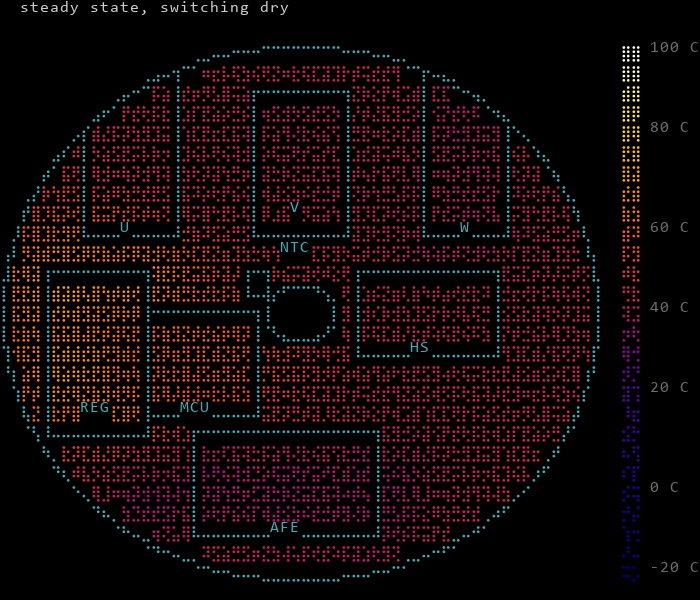

In [6]:
from coaxial.draw import thermalmap
from machine import ansi

steady = thermal.steady(thermal.POWER_SWITCHING)
print('power while switching, dry: %.2f W' % sum(thermal.POWER_SWITCHING.values()))
for node in thermal.ALL_NODES:
    print('%-12s %6.2f C' % (node, steady[node]))
ntc_steady = thermal.expected_ntc(steady['board'], steady[thermal.NTC_PATCH] - steady['board'])
print('NTC expected %.2f C between the centre and the V patch' % ntc_steady)
print('settled: ' + ', '.join('%d min %.0f %%' % (m, 100 * thermal.settled_fraction(m))
                              for m in (1, 5, 10, 25)))
ansi.image(thermalmap.render({n: steady[n] for n in thermal.NODES}, steady['board'],
                             cells=60, colour=True, title='steady state, switching dry'))

## 3 The board's own estimate, and its budget

`state()`: nodes in C and `error` (expected NTC - measured). `ntc` None while AFE_ON is low. `budget()`: `used`, the fraction of each node's span to its record ceiling.

In [7]:
from coaxial.devices.thermal import THROTTLE_AT

observer = device.thermal
st = observer.state()
print('NTC %s C  ambient %.1f C (estimated)  expected NTC %.2f C  error %s  settled %s'
      % (st['ntc'], st['ambient'], st['expected_ntc'], st['error'], st['settled']))
print('other dies: afe %s C, mcu %s C, seen %.1f s ago; %d integration steps'
      % (st['afe'], st['mcu'], st['seen_s_ago'], st['steps']))
cal = device.calibration.read()
budget = observer.budget()
limits = dict(zip(thermal.ALL_NODES, cal['soa_limit_c']))
print('written in the record: %d ceilings, throttle %.2f; where none is written: '
      'silicon %.0f C, laminate %.0f, motor %.0f, throttle at %.2f of the span'
      % (len(limits), cal['soa_throttle_at'], thermal.CEILING_DEFAULT_C,
         thermal.CEILING_C['board'], thermal.CEILING_C['winding'], THROTTLE_AT))
for node in thermal.ALL_NODES:
    print('%-12s %6.2f C  used %5.1f %%  ceiling %s'
          % (node, st['nodes'][node], 100.0 * budget['used'][node],
             '%.1f C' % limits[node] if node in limits else 'none written'))
print('worst %s at %.1f %% of its span; throttling %s, tripped %s, trips %d, derate %.2f'
      % (budget['worst_node'], 100.0 * budget['worst'], budget['throttling'],
         budget['tripped'], budget['trips'], budget['derate']))
print('sample every 30 s:', observer.configure(sample_every_s=30.0, sample_settle_s=0.5),
      observer.state()['sample_every_s'])

NTC None C  ambient 25.0 C (estimated)  expected NTC 25.00 C  error None  settled False
other dies: afe None C, mcu None C, seen 0.0 s ago; 7 integration steps


written in the record: 20 ceilings, throttle 0.90; where none is written: silicon 125 C, laminate 105, motor 120, throttle at 0.90 of the span
driver_u      25.00 C  used   0.0 %  ceiling 125.0 C
driver_v      25.00 C  used   0.0 %  ceiling 125.0 C
driver_w      25.00 C  used   0.0 %  ceiling 125.0 C
phase_u       25.00 C  used   0.0 %  ceiling 125.0 C
phase_v       25.00 C  used   0.0 %  ceiling 125.0 C
phase_w       25.00 C  used   0.0 %  ceiling 125.0 C
mcu           25.51 C  used   0.4 %  ceiling 125.0 C
regulators    25.45 C  used   0.4 %  ceiling 125.0 C
afe           25.00 C  used   0.0 %  ceiling 125.0 C
board         25.00 C  used   0.0 %  ceiling 105.0 C
hotswap       25.00 C  used   0.0 %  ceiling 125.0 C
patch_u       25.00 C  used   0.0 %  ceiling 105.0 C
patch_v       25.00 C  used   0.0 %  ceiling 105.0 C
patch_w       25.00 C  used   0.0 %  ceiling 105.0 C
patch_left    25.00 C  used   0.0 %  ceiling 105.0 C
patch_bottom  25.00 C  used   0.0 %  ceiling 105.0 C
patch_rig

sample every 30 s: {'sample': True} 30.0


Defaults with no ceiling written: 125 C silicon, 105 laminate, 120 motor.

## 4 The envelope

Quiet, switching dry, under current, cooling. Throttle at 90 % of the span: 115 C for silicon in a 25 C room. Conduction split FET 1.8 mohm / shunt 3.5 mohm.

In [8]:
from motor import catalog

R_PHASE = inverter.RDS_ON + inverter.SHUNT
THROTTLE_C = thermal.AMBIENT + THROTTLE_AT * (thermal.CEILING_DEFAULT_C - thermal.AMBIENT)
STATES = (('quiet, no PWM', 0.0, False),
          ('switching, no current', 0.0, True),
          ('switching, 10 A of iq', 10.0, True),
          ('switching, 20 A of iq', 20.0, True),
          ('switching, 60 A of iq', 60.0, True))
print('%-24s %6s %8s %10s %11s   %s' % ('', 'W', 'board C', 'worst C', 'which', 'holdable'))
holdable = {}
for name, iq, on in STATES:
    power = thermal.phase_power(iq / math.sqrt(2.0), R_PHASE, switching=on)
    at = thermal.steady(power)
    worst = max(thermal.NODES, key=lambda n: at[n])
    holdable[name] = (at, at[worst] <= THROTTLE_C)
    print('%-24s %6.2f %8.1f %10.1f %11s   %s'
          % (name, sum(power.values()), at['board'], at[worst], thermal.pretty(worst),
             'yes' if holdable[name][1] else 'NO - a burst, timed below'))
rms = thermal.continuous_amps(R_PHASE, THROTTLE_C)
iq_cont = rms * math.sqrt(2.0)
at = thermal.steady(thermal.phase_power(rms, R_PHASE))
print('continuous: %.1f A rms a phase = %.1f A of iq = %.2f N.m on the 5230SL; '
      'worst node %.1f C against the %.1f C throttle point, board %.1f C'
      % (rms, iq_cont, catalog.KT_NM_PER_AMP * iq_cont,
         max(at[n] for n in thermal.NODES), THROTTLE_C, at['board']))

                              W  board C    worst C       which   holdable
quiet, no PWM              1.80     41.6       69.7  regulators   yes
switching, no current      2.40     44.1       72.3  regulators   yes
switching, 10 A of iq      3.19     47.1       75.4  regulators   yes
switching, 20 A of iq      5.58     55.1       83.7  regulators   yes
switching, 60 A of iq     31.02    106.5      299.8     phase U   NO - a burst, timed below


continuous: 20.0 A rms a phase = 28.3 A of iq = 1.23 N.m on the 5230SL; worst node 115.0 C against the 115.0 C throttle point, board 64.1 C


A burst climbs at `P / capacity`; capacities unmeasured, so the seconds are a band, up to 3x shorter.

In [9]:
tau_board = thermal.tau_minutes()
print('board       %.0f J/K over %.2f K/W = %.1f min'
      % (thermal.CFG['board_capacity'], thermal.CFG['board_to_ambient'], tau_board))
tau_node = {}
for node in ('driver_u', 'phase_u', 'mcu'):
    tau_node[node] = thermal.CFG['capacity'][node] * thermal.CFG['to_board'][node]
    print('%-11s %.2f J/K over %.1f K/W = %.1f s'
          % (thermal.pretty(node), thermal.CFG['capacity'][node],
             thermal.CFG['to_board'][node], tau_node[node]))
print()
print('  iq A   W on the FET node   K/s   W on the shunt   K/s   s to the throttle point from ambient   from a warm board (60 C)')
burst = {}
for iq in (20.0, 40.0, 60.0, 100.0):
    power = thermal.phase_power(iq / math.sqrt(2.0), R_PHASE)   # the FET's conduction and switching, the shunt's conduction
    fet, shunt = power['driver_u'], power['phase_u']
    slope = max(fet / thermal.CFG['capacity']['driver_u'], shunt / thermal.CFG['capacity']['phase_u'])
    burst[iq] = (fet, shunt, slope, (THROTTLE_C - thermal.AMBIENT) / slope, (THROTTLE_C - 60.0) / slope)
    print('%7.0f %17.1f %5.1f %16.1f %5.1f %38.2f %26.2f'
          % (iq, fet, fet / thermal.CFG['capacity']['driver_u'], shunt,
             shunt / thermal.CFG['capacity']['phase_u'], burst[iq][3], burst[iq][4]))

board       49 J/K over 8.33 K/W = 6.8 min
driver U    0.12 J/K over 12.0 K/W = 1.4 s
phase U     0.40 J/K over 8.0 K/W = 3.2 s
mcu         0.90 J/K over 22.5 K/W = 20.2 s

  iq A   W on the FET node   K/s   W on the shunt   K/s   s to the throttle point from ambient   from a warm board (60 C)
     20               0.6   4.8              0.7   1.8                                  18.75                      11.46
     40               1.6  14.1              2.8   7.0                                   6.40                       3.91
     60               3.4  29.5              6.3  15.7                                   3.05                       1.87
    100               9.2  78.9             17.5  43.7                                   1.14                       0.70


Rise over the board `P * to_board` on `capacity * to_board`; the board on 6.8 min.

In [10]:
def rise_after(node, watts, seconds):
    tau = thermal.CFG['capacity'][node] * thermal.CFG['to_board'][node]
    return watts * thermal.CFG['to_board'][node] * (1.0 - math.exp(-seconds / tau))

def seconds_to(node, watts, now_c, ceiling_c):
    tau = thermal.CFG['capacity'][node] * thermal.CFG['to_board'][node]
    top = now_c + watts * thermal.CFG['to_board'][node]
    if top <= ceiling_c:
        return None
    return -tau * math.log(1.0 - (ceiling_c - now_c) / (top - now_c))

def cools_in(rise_k, tau_s, to_k=1.0):
    return tau_s * math.log(rise_k / to_k) if rise_k > to_k else 0.0

for node in ('phase_u', 'driver_u', 'mcu'):
    for watts in (5.0, 15.0, 35.0):
        t = seconds_to(node, watts, st['nodes'][node], THROTTLE_C)
        print('%-9s %5.1f W: +%5.1f K after 100 ms, +%6.1f K steady; the %.0f C throttle point from %.1f C: %s'
              % (node, watts, rise_after(node, watts, 0.1), watts * thermal.CFG['to_board'][node],
                 THROTTLE_C, st['nodes'][node], 'never' if t is None else '%.2f s' % t))
print()
cooling = {}
for node in ('driver_u', 'phase_u'):
    cooling[node] = [cools_in(THROTTLE_C - thermal.AMBIENT, tau_node[node], target) for target in (20.0, 5.0, 1.0)]
    print('%-9s after a burst to the throttle point: to +20 K over the board in %.1f s, +5 K in %.1f, +1 K in %.1f'
          % (node, cooling[node][0], cooling[node][1], cooling[node][2]))
board_cools = {}
for name, (at, holds) in holdable.items():
    if not holds:
        continue
    board_cools[name] = (at['board'] - thermal.AMBIENT, cools_in(at['board'] - thermal.AMBIENT, tau_board * 60.0) / 60.0)
    print('board after %-24s +%5.1f K, back to +1 K in %.0f min' % (name + ':', board_cools[name][0], board_cools[name][1]))

phase_u     5.0 W: +  1.2 K after 100 ms, +  40.0 K steady; the 115 C throttle point from 25.0 C: never
phase_u    15.0 W: +  3.7 K after 100 ms, + 120.0 K steady; the 115 C throttle point from 25.0 C: 4.44 s
phase_u    35.0 W: +  8.6 K after 100 ms, + 280.0 K steady; the 115 C throttle point from 25.0 C: 1.24 s
driver_u    5.0 W: +  4.1 K after 100 ms, +  60.0 K steady; the 115 C throttle point from 25.0 C: never
driver_u   15.0 W: + 12.4 K after 100 ms, + 180.0 K steady; the 115 C throttle point from 25.0 C: 0.97 s
driver_u   35.0 W: + 29.0 K after 100 ms, + 420.0 K steady; the 115 C throttle point from 25.0 C: 0.34 s
mcu         5.0 W: +  0.6 K after 100 ms, + 112.5 K steady; the 115 C throttle point from 25.5 C: 32.14 s
mcu        15.0 W: +  1.7 K after 100 ms, + 337.5 K steady; the 115 C throttle point from 25.5 C: 6.24 s
mcu        35.0 W: +  3.9 K after 100 ms, + 787.5 K steady; the 115 C throttle point from 25.5 C: 2.44 s

driver_u  after a burst to the throttle point: to +20 K

## 5 The tour: the room, the air path and the capacity identified

The stand-in's ground truth: a room, an air-path scale, a capacity scale, identified by `coaxial/kalman/thermal_ident.py` (mirrors `thermal_ident.c`). Rooms 20, -25, 45 C; load 2 min at 30 A, 4 idle; 150 model minutes - the stand-in's whatever MODE is: no board or emulated MCU runs ahead.

In [11]:
standin = device if device.simulated else Coaxial63100(execution_mode=ExecutionMode.SIMULATED).open()
observer = standin.thermal
truth = observer.situation('tour')
print('the board, switched on at %.0f C, carried into %s at %.0f C' % (thermal.AMBIENT, truth['situation'], truth['ambient']))
print('rooms on the tour: ' + ', '.join('%s %.0f C' % (name, observer.SITUATIONS[name]['ambient'])
                                        for name in observer.TOUR))
print('the load cycle:', observer.load_cycle(on_s=120.0, off_s=240.0))
rows, faces = [], {}
last = truth['situation']
for minute in range(1, 151):
    observer.fast_forward(60.0, live=True)
    now, got, truth = observer.state(), observer.identification(), observer.truth()
    if truth['load_a']:
        faces[truth['situation']] = (minute, got['ambient'], dict(now['nodes']))   # each room's last loaded minute
    rows.append({'minute': minute, 'situation': truth['situation'], 'state': got['state'],
                 'margin': got['margin'], 'room': got['ambient'], 'room_sigma': got['ambient_sigma'],
                 'room_truth': truth['ambient'], 'air': got['scales']['air'],
                 'air_sigma': got['sigma']['air'], 'air_truth': truth['air'],
                 'capacity': got['scales']['capacity'], 'capacity_truth': truth['capacity'],
                 'driver_u': now['nodes']['driver_u'],
                 'load_a': truth['load_a'] or 0.0})
    if truth['situation'] != last:
        print('minute %3d: %s -> %s' % (minute, last, truth['situation']))
        last = truth['situation']
stable = [r for r in rows if r['state'] == 'STABLE']
print('%d minutes STABLE of %d; final margin %.2f, room %.1f C for %.0f, air %.2f for %.2f, capacity %.2f for %.2f'
      % (len(stable), len(rows), rows[-1]['margin'], rows[-1]['room'], rows[-1]['room_truth'],
         rows[-1]['air'], rows[-1]['air_truth'], rows[-1]['capacity'], rows[-1]['capacity_truth']))

the board, switched on at 25 C, carried into temperate at 20 C
rooms on the tour: temperate 20 C, cold -25 C, toasty 45 C
the load cycle: {'amps': 30.0, 'on_s': 120.0, 'off_s': 240.0}


minute  12: temperate -> cold


minute  31: cold -> toasty


minute  47: toasty -> temperate


minute  73: temperate -> cold


minute  93: cold -> toasty


minute 112: toasty -> temperate


minute 139: temperate -> cold


16 minutes STABLE of 150; final margin 0.87, room -25.4 C for -25, air 0.98 for 0.90, capacity 1.00 for 1.00


Margin: 0.80 while the model is doubted, 1.0 when not. A room step charges the room, not the air path.

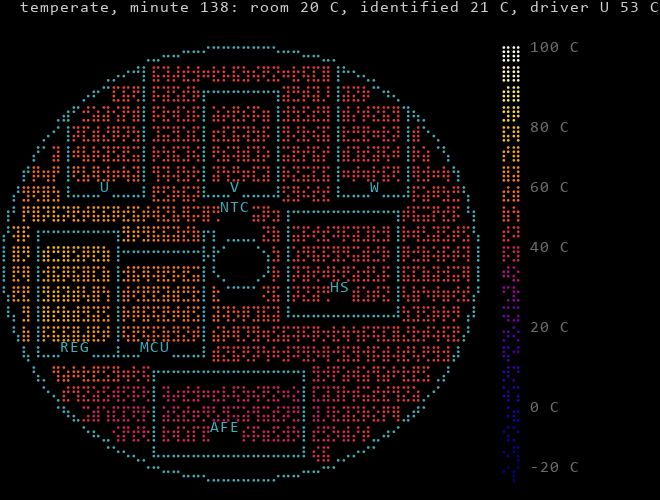

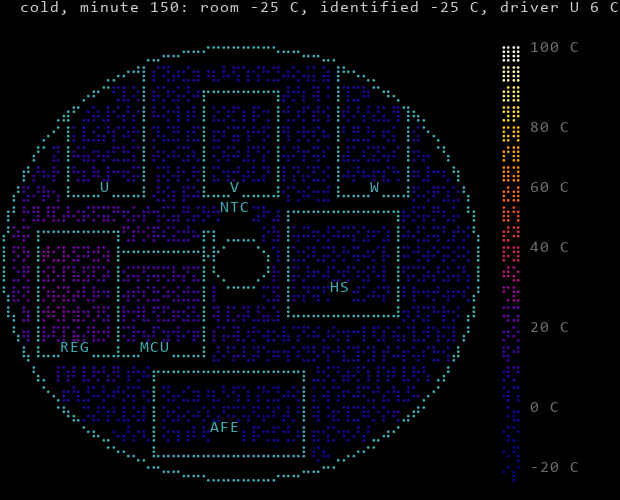

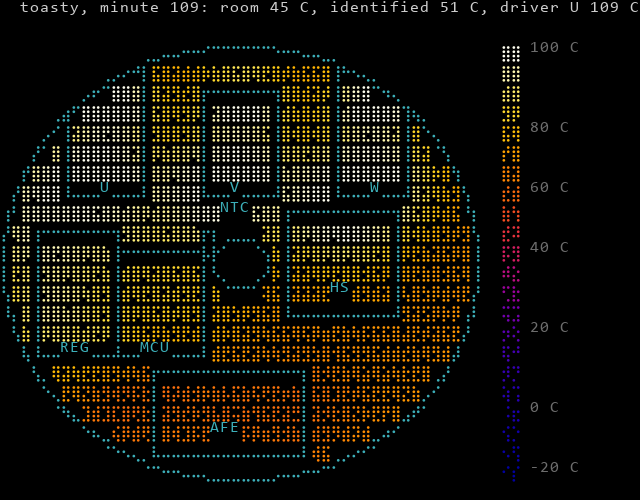

In [12]:
from IPython.display import display

for room in observer.TOUR:
    if room not in faces:
        continue
    minute, found, nodes = faces[room]
    display(ansi.image(thermalmap.render({n: nodes[n] for n in thermal.NODES}, nodes['board'],
                                         cells=48, colour=True,
                                         title='%s, minute %d: room %.0f C, identified %.0f C, driver U %.0f C'
                                               % (room, minute, observer.SITUATIONS[room]['ambient'],
                                                  found, nodes['driver_u']))))

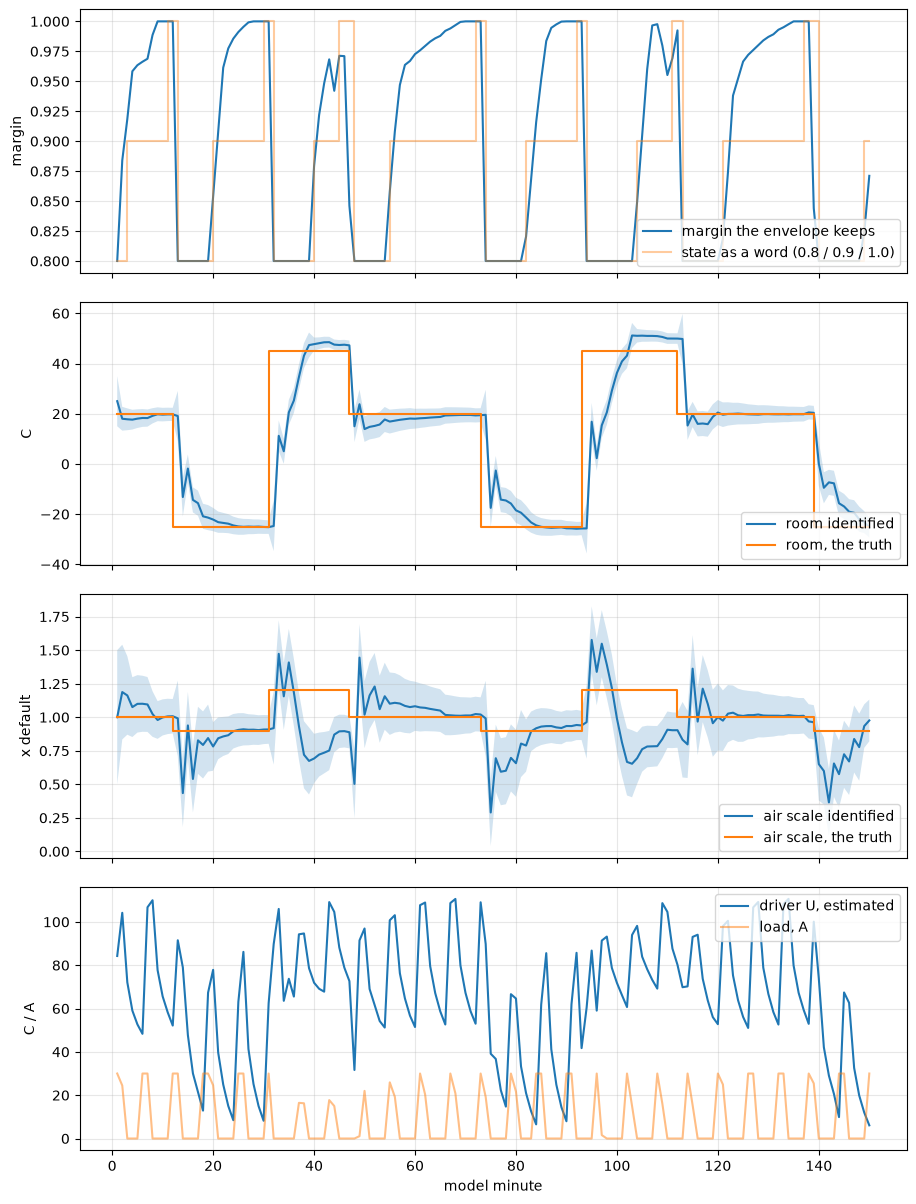

In [13]:
from coaxial.draw.figures import figure, show

t = [r['minute'] for r in rows]
fig, (top, room, air, load) = figure(rows=4, sharex=True)
top.plot(t, [r['margin'] for r in rows], label='margin the envelope keeps')
top.step(t, [{'UNCERTAIN': 0.8, 'CONVERGING': 0.9, 'STABLE': 1.0}[r['state']] for r in rows],
         where='post', alpha=0.4, label='state as a word (0.8 / 0.9 / 1.0)')
top.set_ylabel('margin')
top.legend(loc='lower right')
room.plot(t, [r['room'] for r in rows], label='room identified')
room.fill_between(t, [r['room'] - r['room_sigma'] for r in rows],
                  [r['room'] + r['room_sigma'] for r in rows], alpha=0.2)
room.step(t, [r['room_truth'] for r in rows], where='post', label='room, the truth')
room.set_ylabel('C')
room.legend(loc='lower right')
air.plot(t, [r['air'] for r in rows], label='air scale identified')
air.fill_between(t, [r['air'] - r['air_sigma'] for r in rows],
                 [r['air'] + r['air_sigma'] for r in rows], alpha=0.2)
air.step(t, [r['air_truth'] for r in rows], where='post', label='air scale, the truth')
air.set_ylabel('x default')
air.legend(loc='lower right')
load.plot(t, [r['driver_u'] for r in rows], label='driver U, estimated')
load.plot(t, [r['load_a'] for r in rows], alpha=0.5, label='load, A')
load.set_ylabel('C / A')
load.set_xlabel('model minute')
load.legend(loc='upper right')
show(fig)

## 6 A trip

A trip drops MOE; the margin is capped at 0.70 and returns 1 %/min. Armed on the stand-in, cold room, 200 A three phases for 2 min, then 38 idle.

In [14]:
print('load cycle off:', observer.load_cycle(0))
truth = observer.situation('cold')
print('carried into %s at %.0f C' % (truth['situation'], truth['ambient']))
print('stage armed:', standin.gates.on(bypass_sto=True, ignore_interlock=True)['pwm_enabled'])
cooked = {'amps': (200.0, 200.0, 200.0), 'switching': True}
idle = {'amps': (0.0, 0.0, 0.0), 'switching': False}
trace = []
for minute in range(1, 41):
    observer.fast_forward(60.0, seen=cooked if minute <= 2 else idle, live=True)
    b, got = observer.budget(), observer.identification()
    armed = standin.gates.is_on()
    trace.append((minute, got['margin'], b['trips'], got['trip_cap'], armed))
    if minute in (1, 2, 3, 5, 10, 20, 30, 40):
        print('minute %2d: trips %d, stage armed %-5s worst %.2f of the span in force, '
              'trip cap %.2f, margin %.2f, %s'
              % (minute, b['trips'], armed, b['worst'], got['trip_cap'],
                 got['margin'], got['state']))
released = standin.gates.off()
print('released: pwm_enabled %s, break_bypassed %s'
      % (released['pwm_enabled'], released['break_bypassed']))
if standin is not device:
    standin.close()

load cycle off: {'amps': 0.0, 'on_s': 0.0, 'off_s': 0.0}
carried into cold at -25 C
stage armed: True


minute  1: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.71, margin 0.71, CONVERGING


minute  2: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.72, margin 0.72, CONVERGING


minute  3: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.73, margin 0.73, CONVERGING


minute  5: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.75, margin 0.75, STABLE


minute 10: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.80, margin 0.80, STABLE


minute 20: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.90, margin 0.90, STABLE


minute 30: trips 1, stage armed False worst 1.00 of the span in force, trip cap 1.00, margin 1.00, STABLE


minute 40: trips 1, stage armed False worst 0.61 of the span in force, trip cap 1.00, margin 1.00, STABLE
released: pwm_enabled False, break_bypassed False


In [15]:
device.close()
print(device)

<Coaxial63100 Emulated MCU at emulator:// closed>


## 7 Results

In [16]:
moves = [r['minute'] for a, r in zip(rows, rows[1:]) if a['situation'] != r['situation']]
before = [rows[m - 2] for m in moves]          # each leg's last minute, before the move
print('1. the network     %d nodes; board %.2f K/W and %.0f J/K, tau %.1f min - the two measured numbers; '
      'a leg %.0f K/W between the camera\'s %.1f and the coupon\'s %.1f'
      % (len(thermal.ALL_NODES), thermal.CFG['board_to_ambient'], thermal.CFG['board_capacity'],
         tau_board, thermal.LEG_TO_BOARD, camera_leg, sheet_leg))
print('2. the NTC         %.1f K over the board at rest, %.2f of the V leg\'s rise, lag %.0f s; '
      'the switching state misses by %.1f K, %.1f of it that offset'
      % (thermal.NTC_OFFSET, thermal.NTC_SEES_DRIVERS, thermal.NTC_TAU_S, thermal.NTC_CAMPAIGN_RESIDUAL_K,
         thermal.NTC_OFFSET))
print('3. the fit         mcu %.1f and regulators %.1f K/W off the passive state, the graph\'s %.1f and %.1f; '
      'bridge %.1f K/W lumped'
      % (fit['mcu'], fit['regulators'], thermal.CFG['to_board']['mcu'],
         thermal.CFG['to_board']['regulators'], bridge_lumped))
print('4. switching dry   %.2f W: board %.1f C, %s the hottest at %.1f C, NTC expected %.2f C; '
      '25 min is %.0f %% of the way'
      % (sum(thermal.POWER_SWITCHING.values()), steady['board'],
         max(thermal.NODES, key=lambda n: steady[n]), max(steady[n] for n in thermal.NODES),
         ntc_steady, 100 * thermal.settled_fraction(25)))
print('5. the board       NTC %s C, error %s, worst %s at %.1f %%; ceilings written %d, throttle %.2f '
      'in the record, %.2f the default'
      % (st['ntc'], st['error'], budget['worst_node'], 100.0 * budget['worst'], len(limits),
         cal['soa_throttle_at'], THROTTLE_AT))
print('6. holdable        ' + '; '.join('%s: board %.1f C, worst %.1f' % (name, at['board'], max(at[n] for n in thermal.NODES))
                                        for name, (at, holds) in holdable.items() if holds))
print('7. continuous      %.1f A rms a phase = %.1f A of iq = %.2f N.m against the %.0f C throttle point'
      % (rms, iq_cont, catalog.KT_NM_PER_AMP * iq_cont, THROTTLE_C))
print('8. a burst         driver %.1f s, shunt %.1f s, board %.1f min; 60 A of iq: %.1f W on the FET, %.1f on the shunt, '
      '%.0f K/s, %.1f s to the throttle point from ambient, %.1f from 60 C; cold to +1 K over the board in %.1f s'
      % (tau_node['driver_u'], tau_node['phase_u'], tau_board, burst[60.0][0], burst[60.0][1], burst[60.0][2],
         burst[60.0][3], burst[60.0][4], max(cooling['driver_u'][2], cooling['phase_u'][2])))
print('9. the board cools %s' % '; '.join('%s +%.1f K, back to +1 K in %.0f min' % (name, rise, minutes)
                                          for name, (rise, minutes) in board_cools.items()))
print('10. the tour       moved at minutes %s; STABLE %d of %d, the margin at the floor %d minutes, whole %d'
      % (moves, len(stable), len(rows), sum(1 for r in rows if r['margin'] <= thermal.IDENT_MARGIN_FLOOR + 1e-9),
         sum(1 for r in rows if r['margin'] >= 0.999)))
print('    the room       at each leg\'s end: ' + ', '.join('%.1f for %.0f' % (r['room'], r['room_truth']) for r in before)
      + '; worst %.1f K' % max(abs(r['room'] - r['room_truth']) for r in before))
print('    the air path   at each leg\'s end: ' + ', '.join('%.2f for %.2f' % (r['air'], r['air_truth']) for r in before)
      + '; capacity %.2f for %.2f at the end' % (rows[-1]['capacity'], rows[-1]['capacity_truth']))
print('11. the trip       %d trip, stage armed after it: %s; margin %.2f the minute after, %.2f at minute 10, '
      '%.2f at 20, %.2f at 30, %.2f at 40; the cap %.2f -> %.2f'
      % (trace[-1][2], trace[0][4], trace[0][1], trace[9][1], trace[19][1], trace[29][1], trace[39][1],
         trace[0][3], trace[-1][3]))

1. the network     20 nodes; board 8.33 K/W and 49 J/K, tau 6.8 min - the two measured numbers; a leg 28 K/W between the camera's 45.5 and the coupon's 16.9
2. the NTC         6.0 K over the board at rest, 0.30 of the V leg's rise, lag 215 s; the switching state misses by 13.9 K, 6.0 of it that offset
3. the fit         mcu 22.5 and regulators 15.0 K/W off the passive state, the graph's 22.5 and 15.0; bridge 15.2 K/W lumped
4. switching dry   2.40 W: board 44.1 C, regulators the hottest at 72.3 C, NTC expected 43.29 C; 25 min is 97 % of the way
5. the board       NTC None C, error None, worst rotor at 0.0 %; ceilings written 20, throttle 0.90 in the record, 0.90 the default
6. holdable        quiet, no PWM: board 41.6 C, worst 69.7; switching, no current: board 44.1 C, worst 72.3; switching, 10 A of iq: board 47.1 C, worst 75.4; switching, 20 A of iq: board 55.1 C, worst 83.7
7. continuous      20.0 A rms a phase = 28.3 A of iq = 1.23 N.m against the 115 C throttle point
8. a burst    

- Board 8.33 K/W, 49 J/K: 6.8 min. NTC +6.0 K over the board at rest.
- 2.40 W switching dry; the regulators hottest at 72.3 C.
- Continuous ~20 A rms a phase; 60 A of iq lasts 3 s.
- Taken dry: at 100 A of iq the shunt alone is 17.5 W a phase, against the camera's 1.20 W of switching.

**Bench.** `error` first. Capacities: `dT/dt` right after a power step (`tools/bench/pulse.py`) is `P / capacity`.

## References

* `host/coaxial/model/thermal.py` - the network on the host: the nodes, the edges, the campaign's table, and every constant's argument
* `thermal/src/thermal.c` - the same network as the board integrates it, and the envelope
* `host/coaxial/kalman/thermal_ident.py` - the identification the stand-in runs, mirroring `thermal/src/thermal_ident.c`
* `host/coaxial/devices/thermal.py` - `device.thermal`: state, budget, identification, the record's ceilings and the sample interval
* `host/coaxial/simulated/thermal/` - the stand-in: a hypothetical board with a ground truth, the situations, the tour and the trip cap
* `docs/HARDWARE.md` - the campaign, the camera, and how a measurement here is to be read
* `docs/FINDINGS.md` - the camera campaign, the two measured numbers, the envelope's 100 ms slice, the identification against a ground truth
* `host/tests/test_thermal_core.py` - the envelope as the C that will run, and the identification against a ground truth